In [21]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import solve

In [22]:
# PROBLEMA
##############################################################################

def f(x):
    return np.sin(2*np.pi*x)

def u_exacta(x):
    return (
        (x-1)/(2*np.pi)
        -
        np.sin(2*np.pi*x)/(4*np.pi**2)
    )

In [23]:
# MATRIZ CASO (a)
##############################################################################

def matriz_forward_orden1(m,h):

    N = m + 1

    A = np.zeros((N,N))

    # Neumann
    A[0,0] = -1
    A[0,1] = 1

    # Interior
    for i in range(1,m):

        A[i,i-1] = 1/h**2
        A[i,i]   = -2/h**2
        A[i,i+1] = 1/h**2

    # Último nodo antes de x=1
    A[m,m-1] = 1/h**2
    A[m,m]   = -2/h**2

    return A

In [24]:
# MATRIZ CASO (b)
##############################################################################

def matriz_nodo_ficticio(m,h):

    N = m+1

    A = np.zeros((N,N))

    A[0,0] = -2/h**2
    A[0,1] =  2/h**2

    for i in range(1,m):

        A[i,i-1] = 1/h**2
        A[i,i]   = -2/h**2
        A[i,i+1] = 1/h**2

    A[m,m-1] = 1/h**2
    A[m,m]   = -2/h**2

    return A

In [25]:
# MATRIZ CASO (c)
##############################################################################

def matriz_forward_orden2(m,h):

    N = m+1

    A = np.zeros((N,N))

    A[0,0] = -3
    A[0,1] = 4
    A[0,2] = -1

    for i in range(1,m):

        A[i,i-1] = 1/h**2
        A[i,i]   = -2/h**2
        A[i,i+1] = 1/h**2

    A[m,m-1] = 1/h**2
    A[m,m]   = -2/h**2

    return A

In [26]:
# RESOLUCIÓN
##############################################################################

def resolver(m,tipo):

    h = 1/(m+1)

    x = np.linspace(0,1,m+2)

    if tipo=="a":
        A = matriz_forward_orden1(m,h)

    elif tipo=="b":
        A = matriz_nodo_ficticio(m,h)

    else:
        A = matriz_forward_orden2(m,h)

    b = np.zeros(m+1)

    # condición de Neumann
    b[0] = 0

    # ecuaciones interiores
    for i in range(1,m+1):
        b[i] = f(x[i])

    for i in range(m):
        b[i] = f(x[i])

    # Dirichlet en x=1
    b[m] -= 0/(h*h)

    u_aux = solve(A,b)

    u_num = np.concatenate((u_aux,[0]))

    u_ex = u_exacta(x)

    error = np.max(np.abs(u_num-u_ex))

    return x,u_num,u_ex,error

m=[10,20,40,80,160]  Método a: orden observado = 2.0018
m=[10,20,40,80,160]  Método b: orden observado = 2.0018
m=[10,20,40,80,160]  Método c: orden observado = 1.9776
m=[2^3,...,2^8]  Método a: orden observado = 2.0020
m=[2^3,...,2^8]  Método b: orden observado = 2.0020
m=[2^3,...,2^8]  Método c: orden observado = 1.9749


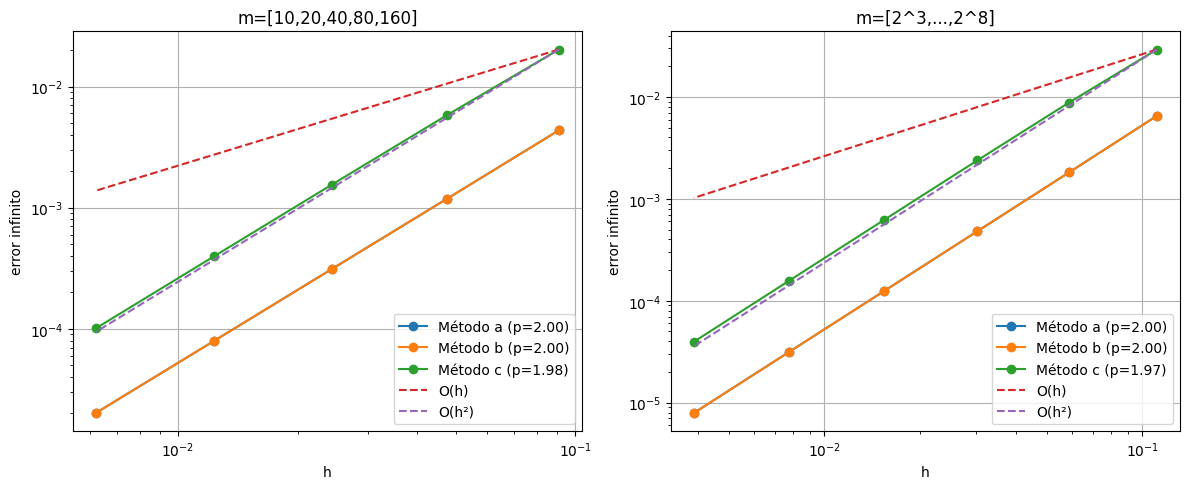

In [27]:
import numpy as np
import matplotlib.pyplot as plt

##############################################################################
# DOS FAMILIAS DE MALLAS
##############################################################################

mallas = {
    "m=[10,20,40,80,160]":
        [10,20,40,80,160],

    "m=[2^3,...,2^8]":
        [2**k for k in range(3,9)]
}

##############################################################################
# GRAFICOS
##############################################################################

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

for ax, (titulo, ms) in zip(axes, mallas.items()):

    # recorrer los tres métodos
    for metodo in ["a","b","c"]:

        hs = []
        errores = []

        for m in ms:

            h = 1/(m+1)

            _, _, _, error = resolver(m, metodo)

            hs.append(h)
            errores.append(error)

        hs = np.array(hs)
        errores = np.array(errores)

        ######################################################################
        # Ajuste lineal en escala log-log
        ######################################################################

        pendiente, ordenada = np.polyfit(
            np.log(hs),
            np.log(errores),
            1
        )

        print(
            f"{titulo}  Método {metodo}: "
            f"orden observado = {pendiente:.4f}"
        )

        ######################################################################
        # Gráfico
        ######################################################################

        ax.loglog(
            hs,
            errores,
            'o-',
            label=f"Método {metodo} (p={pendiente:.2f})"
        )
        
    C1 = errores[0] / hs[0]
    C2 = errores[0] / hs[0]**2

    ax.loglog(
        hs,
        C1*hs,
        '--',
        label='O(h)'
    )

    ax.loglog(
        hs,
        C2*hs**2,
        '--',
        label='O(h²)'
    )

    ax.set_title(titulo)
    ax.set_xlabel("h")
    ax.set_ylabel("error infinito")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [28]:
for metodo in ["a","b","c"]:

    print(f"\nMétodo {metodo}")

    for m in [10,20,40,80,160]:

        _,_,_,error = resolver(m,metodo)

        print(m,error)


Método a
10 0.004350977687838542
20 0.0011890740492934981
40 0.0003116025200730621
80 7.981272557777697e-05
160 2.020030350202706e-05

Método b
10 0.004350977687838514
20 0.0011890740492926932
40 0.00031160252007184086
80 7.981272557899821e-05
160 2.0200303499556815e-05

Método c
10 0.020223604923779448
20 0.00582890629382421
40 0.0015499741167431802
80 0.0003985355501760768
160 0.00010096767846165533


     N | e_m caso a | e_m caso b | e_m caso c
    10 | 5.271e-03 | 5.271e-03 | 2.412e-02
    20 | 1.311e-03 | 1.311e-03 | 6.414e-03
    40 | 3.274e-04 | 3.274e-04 | 1.628e-03
    80 | 8.182e-05 | 8.182e-05 | 4.085e-04
   160 | 2.045e-05 | 2.045e-05 | 1.022e-04
   320 | 5.113e-06 | 5.113e-06 | 2.556e-05

Orden de convergencia estimado (log2 de la razón de errores al duplicar N):
  Caso a (Forward (orden 1)): ['2.01', '2.00', '2.00', '2.00', '2.00']
  Caso b (Centrada + nodo ficticio (orden 2)): ['2.01', '2.00', '2.00', '2.00', '2.00']
  Caso c (Forward orden 2): ['1.91', '1.98', '1.99', '2.00', '2.00']

Gráficos guardados: solucion.png, convergencia.png


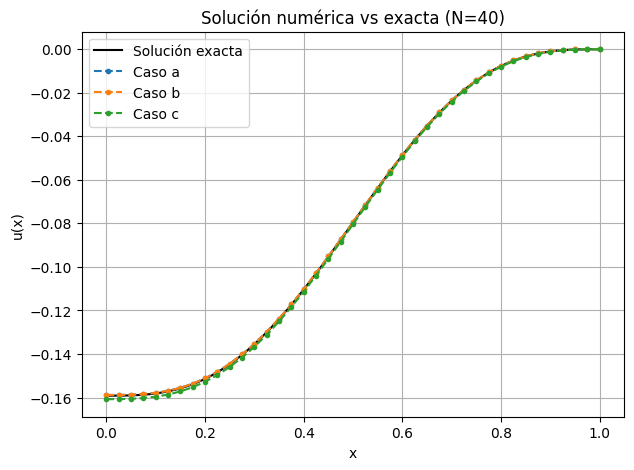

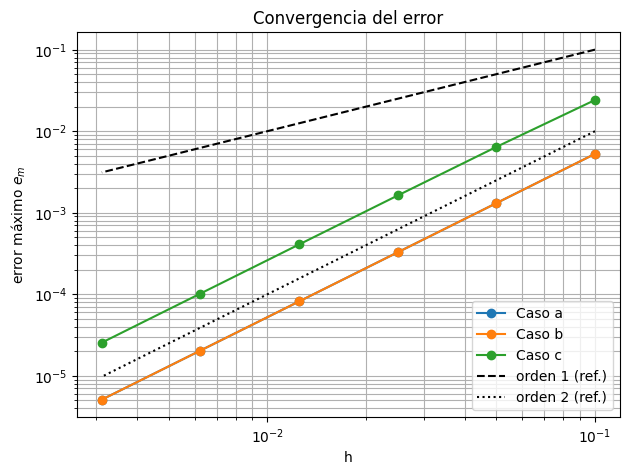

In [31]:
"""
Ejercicio 6: u_xx = f(x), x en (0,1)
Condiciones: u_x(0) = 0 (Neumann),  u(1) = 0 (Dirichlet)

Se discretiza con paso h = 1/N, nodos x_i = i*h, i = 0,...,N.
Como U_N = 0 es dato (Dirichlet), las incógnitas son U_0,...,U_{N-1}.

Ecuaciones interiores (i = 1,...,N-1), iguales en los 3 casos:
    (U_{i-1} - 2U_i + U_{i+1}) / h^2 = f(x_i)

La única diferencia entre los casos es la ECUACIÓN EN x=0 (fila 0):

 (a) Forward (orden 1):           (U_1 - U_0)/h = 0
 (b) Centrada + nodo ficticio:    U_{-1} = U_1  =>  (2U_1 - 2U_0)/h^2 = f(x_0)
 (c) Forward de orden 2:          (3/2 U_0 - 2 U_1 + 1/2 U_2)/h = 0
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------- Problema ----------
f = lambda x: np.sin(2*np.pi*x)

# Solución exacta de u_xx = sin(2*pi*x), u_x(0)=0, u(1)=0
# (obtenida integrando dos veces y usando las condiciones de borde)
u_exact = lambda x: (x - 1)/(2*np.pi) - np.sin(2*np.pi*x)/(4*np.pi**2)


def resolver(N, caso):
    """Devuelve el vector U (de tamaño N+1, incluyendo U_N=0) en la malla x_i=i*h."""
    h = 1.0 / N
    x = np.linspace(0, 1, N+1)

    # Incógnitas: U_0,...,U_{N-1}  (U_N = 0 es dato Dirichlet)
    A = np.zeros((N, N))
    b = np.zeros(N)

    # --- Fila 0: condición de Neumann en x=0 ---
    if caso == 'a':  # forward, orden 1
        A[0, 0] = -1/h
        A[0, 1] = 1/h
        b[0] = 0.0
    elif caso == 'b':  # centrada + nodo ficticio
        A[0, 0] = -2/h**2
        A[0, 1] = 2/h**2
        b[0] = f(x[0])
    elif caso == 'c':  # forward orden 2
        A[0, 0] = 1.5/h
        A[0, 1] = -2/h
        A[0, 2] = 0.5/h
        b[0] = 0.0
    else:
        raise ValueError("caso debe ser 'a', 'b' o 'c'")

    # --- Filas interiores i=1,...,N-1: misma ecuación en los 3 casos ---
    for i in range(1, N):
        b[i] = f(x[i])
        A[i, i-1] = 1/h**2
        A[i, i] = -2/h**2
        if i+1 <= N-1:
            A[i, i+1] = 1/h**2
        # si i+1 == N, U_N=0 y no aporta término (ya es 0)

    U_interior = np.linalg.solve(A, b)
    U = np.concatenate([U_interior, [0.0]])  # agrega U_N = 0
    return x, U


# ---------- Estudio de convergencia ----------
casos = {'a': 'Forward (orden 1)',
         'b': 'Centrada + nodo ficticio (orden 2)',
         'c': 'Forward orden 2'}

Ns = [10, 20, 40, 80, 160, 320]

print(f"{'N':>6} | " + " | ".join(f"e_m caso {c}" for c in casos))
errores = {c: [] for c in casos}
for N in Ns:
    fila = [f"{N:>6}"]
    for c in casos:
        x, U = resolver(N, c)
        e_m = np.max(np.abs(U - u_exact(x)))
        errores[c].append(e_m)
        fila.append(f"{e_m:.3e}")
    print(" | ".join(fila))

print("\nOrden de convergencia estimado (log2 de la razón de errores al duplicar N):")
for c in casos:
    ordenes = [np.log2(errores[c][i]/errores[c][i+1]) for i in range(len(Ns)-1)]
    print(f"  Caso {c} ({casos[c]}): {[f'{o:.2f}' for o in ordenes]}")

# ---------- Gráfico solución numérica vs exacta (N=40) ----------
plt.figure(figsize=(7, 5))
xx = np.linspace(0, 1, 400)
plt.plot(xx, u_exact(xx), 'k-', label='Solución exacta')
for c in casos:
    x, U = resolver(40, c)
    plt.plot(x, U, 'o--', label=f"Caso {c}", markersize=3)
plt.xlabel('x'); plt.ylabel('u(x)')
plt.title('Solución numérica vs exacta (N=40)')
plt.legend(); plt.grid(True)


# ---------- Gráfico log-log del error ----------
plt.figure(figsize=(7, 5))
hs = [1.0/N for N in Ns]
for c in casos:
    plt.loglog(hs, errores[c], 'o-', label=f"Caso {c}")
plt.loglog(hs, [h for h in hs], 'k--', label='orden 1 (ref.)')
plt.loglog(hs, [h**2 for h in hs], 'k:', label='orden 2 (ref.)')
plt.xlabel('h'); plt.ylabel('error máximo $e_m$')
plt.title('Convergencia del error')
plt.legend(); plt.grid(True, which='both')


print("\nGráficos guardados: solucion.png, convergencia.png")